# Q2 (Part 2) — Genetic Algorithm: Minimize f(x) = -x^2 + 2x

**Aim:** Minimize $f(x) = -x^2 + 2x$ for $0 \le x \le 2$, using 5-bit chromosomes decoded via
$x = min + \frac{max-min}{2^L-1}\times(\text{decimal value})$, with $min=0$, $max=2$, $L=5$.

**Algorithm**
- Initialize population (chromosomes), decode to $x$, evaluate $f(x)$.
- Convert to a maximization-style fitness: $\text{fitness}(x) = \frac{1}{1+f(x)}$ (smaller $f(x) \Rightarrow$ larger fitness).
- Compute selection probability and cumulative probability; select via roulette wheel.
- Build the mating pool, apply single-point crossover.
- Apply mutation (bit-flip) with a small probability.
- Form the new population; repeat until a stopping/convergence criterion is met.
- Return the best (lowest-$f(x)$) solution found.

## Key Parameter Settings

In [1]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

MIN_X, MAX_X, L = 0, 2, 5

def f(x):
    return -x**2 + 2*x

def decode(chromosome: str) -> float:
    decimal_value = int(chromosome, 2)
    return MIN_X + (MAX_X - MIN_X) / (2**L - 1) * decimal_value

def ga_fitness(x):
    return 1 / (1 + f(x))   # minimization -> maximization transform

INIT_POPULATION = ['11010', '00111', '10110', '00101']
CHROM_LEN     = 5
POP_SIZE      = 4
GENERATIONS   = 30
MUTATION_RATE = 0.02

print(f"Check: decode('10110') = {decode('10110'):.3f}  (expected 1.419)")
print(f"Objective        : f(x) = -x^2+2x, domain [{MIN_X}, {MAX_X}]")
print(f"Population size   : {POP_SIZE}, Generations: {GENERATIONS}, Mutation rate: {MUTATION_RATE}")

Check: decode('10110') = 1.419  (expected 1.419)
Objective        : f(x) = -x^2+2x, domain [0, 2]
Population size   : 4, Generations: 30, Mutation rate: 0.02


## Step 1 — Initial Population, Fitness, Selection (hand-worked, Generation 1)

In [2]:
x_values = [decode(c) for c in INIT_POPULATION]
f_values = [f(x) for x in x_values]
fit_values = [ga_fitness(x) for x in x_values]
total_fit = sum(fit_values)
prob = [v / total_fit for v in fit_values]
cum_prob = np.cumsum(prob)

gen1 = pd.DataFrame({
    'String No.': range(1, 5), 'Chromosome': INIT_POPULATION,
    'x': np.round(x_values, 4), 'f(x)': np.round(f_values, 4),
    'Fitness=1/(1+f)': np.round(fit_values, 4), 'Probability': np.round(prob, 4),
    'Cumulative Prob.': np.round(cum_prob, 4)
})
gen1

,String No.,Chromosome,x,f(x),Fitness=1/(1+f),Probability,Cumulative Prob.
0,1,11010,1.6774,0.5411,0.6489,0.2665,0.2665
1,2,00111,0.4516,0.6993,0.5885,0.2417,0.5083
2,3,10110,1.4194,0.8241,0.5482,0.2252,0.7335
3,4,00101,0.3226,0.5411,0.6489,0.2665,1.0000


## Step 2 — Selection with given random numbers (hand-worked)

In [3]:
random_numbers = [0.40, 0.15, 0.70, 0.90]

def select_by_cum_prob(r, cum_prob):
    for i, cp in enumerate(cum_prob):
        if r <= cp:
            return i
    return len(cum_prob) - 1

selected = [select_by_cum_prob(r, cum_prob) for r in random_numbers]
mating_pool = [INIT_POPULATION[i] for i in selected]
pd.DataFrame({'Random no. r': random_numbers, 'Selected String No.': [i + 1 for i in selected],
              'Selected Chromosome': mating_pool})

,Random no. r,Selected String No.,Selected Chromosome
0,0.40,2,00111
1,0.15,1,11010
2,0.70,3,10110
3,0.90,4,00101


## Core Algorithm (function definitions)

In [4]:
def crossover(parent_a: str, parent_b: str, site: int):
    return parent_a[:site] + parent_b[site:], parent_b[:site] + parent_a[site:]

def mutate(chromosome: str, rate: float, rng: random.Random) -> str:
    bits = list(chromosome)
    for i in range(len(bits)):
        if rng.random() < rate:
            bits[i] = '1' if bits[i] == '0' else '0'
    return ''.join(bits)

def roulette_select(population, weights, rng: random.Random):
    return rng.choices(population, weights=weights, k=1)[0]

def genetic_algorithm_min(init_population, decode_fn, obj_fn, fitness_fn, generations,
                           mutation_rate, chrom_len, rng=None, verbose_every=5, patience=6):
    rng = rng or random.Random()
    population = list(init_population)
    history = []
    best_x, best_f = None, float('inf')
    stall = 0

    for gen in range(1, generations + 1):
        x_vals = [decode_fn(c) for c in population]
        obj_vals = [obj_fn(x) for x in x_vals]
        fit_vals = [fitness_fn(x) for x in x_vals]
        gen_best_idx = int(np.argmin(obj_vals))

        if obj_vals[gen_best_idx] < best_f:
            best_f, best_x = obj_vals[gen_best_idx], x_vals[gen_best_idx]
            stall = 0
        else:
            stall += 1

        history.append({"Generation": gen, "Best x": round(x_vals[gen_best_idx], 4),
                         "Best f(x)": round(obj_vals[gen_best_idx], 4),
                         "Avg f(x)": round(np.mean(obj_vals), 4)})

        if verbose_every and gen % verbose_every == 0:
            print(f"Generation {gen:3d} | Best x = {x_vals[gen_best_idx]:.4f} | "
                  f"Best f(x) = {obj_vals[gen_best_idx]:.4f} | Avg f(x) = {np.mean(obj_vals):.4f}")

        if stall >= patience:
            break

        mating_pool = [roulette_select(population, fit_vals, rng) for _ in range(len(population))]
        new_population = []
        for i in range(0, len(mating_pool) - 1, 2):
            c1, c2 = crossover(mating_pool[i], mating_pool[i + 1], rng.randint(1, chrom_len - 1))
            new_population += [mutate(c1, mutation_rate, rng), mutate(c2, mutation_rate, rng)]
        if len(new_population) < len(population):
            new_population.append(mutate(mating_pool[-1], mutation_rate, rng))
        population = new_population

    return best_x, best_f, history

## Program Execution — Full run (repeated until convergence)

In [5]:
best_x, best_f, history = genetic_algorithm_min(
    INIT_POPULATION, decode, f, ga_fitness, GENERATIONS, MUTATION_RATE, CHROM_LEN, rng=random.Random(2)
)

print("\nExecution Status: Successfully Executed")
print(f"Final Optimal Solution : x* = {best_x:.4f}")
print(f"Minimum Function Value : f(x*) = {best_f:.4f}")

hist_df = pd.DataFrame(history)
hist_df

Generation   5 | Best x = 0.1935 | Best f(x) = 0.3496 | Avg f(x) = 0.3746
Generation  10 | Best x = 0.0000 | Best f(x) = 0.0000 | Avg f(x) = 0.0000

Execution Status: Successfully Executed
Final Optimal Solution : x* = 0.0000
Minimum Function Value : f(x*) = 0.0000


,Generation,Best x,Best f(x),Avg f(x)
0,1,0.3226,0.5411,0.6514
1,2,0.3226,0.5411,0.5411
2,3,0.1290,0.2414,0.3913
3,4,0.1935,0.3496,0.3996
4,5,0.1935,0.3496,0.3746
5,6,0.0645,0.1249,0.3871
6,7,0.0645,0.1249,0.3143
7,8,0.0000,0.0000,0.3413
8,9,0.0000,0.0000,0.4246
9,10,0.0000,0.0000,0.0000


## Analytical Verification

In [6]:
x = sp.symbols('x')
f_sym = -x**2 + 2*x
print(f"f(0) = {f_sym.subs(x,0)}, f(2) = {f_sym.subs(x,2)}  -> true minimum f(x)=0 at boundaries x=0, x=2")
print(f"GA best found: x = {best_x:.4f}, f(x) = {best_f:.4f}")

f(0) = 0, f(2) = 0  -> true minimum f(x)=0 at boundaries x=0, x=2
GA best found: x = 0.0000, f(x) = 0.0000


## Convergence Graph

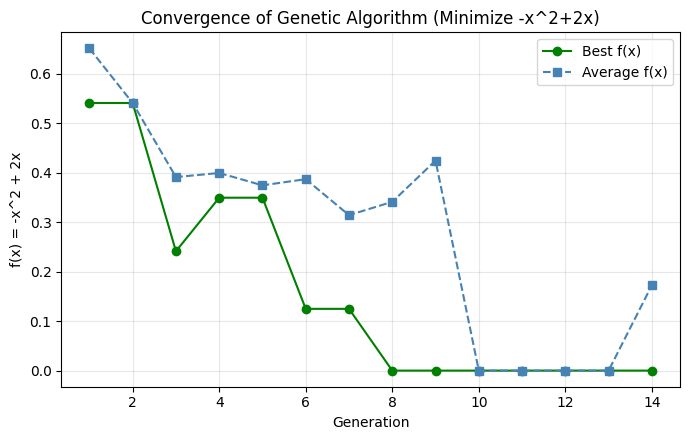

In [7]:
plt.figure(figsize=(7, 4.5))
plt.plot(hist_df['Generation'], hist_df['Best f(x)'], 'o-', color='green', label='Best f(x)')
plt.plot(hist_df['Generation'], hist_df['Avg f(x)'], 's--', color='steelblue', label='Average f(x)')
plt.xlabel('Generation')
plt.ylabel('f(x) = -x^2 + 2x')
plt.title('Convergence of Genetic Algorithm (Minimize -x^2+2x)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Parameter Modification

In [8]:
param_tests = [
    ("Population Size", 4, 8, {"init_population": ['11010', '00111', '10110', '00101',
                                                     '00000', '11111', '01010', '10101']}),
    ("Mutation Rate", MUTATION_RATE, 0.10, {"mutation_rate": 0.10}),
    ("Generations", GENERATIONS, 10, {"generations": 10}),
    ("Crossover Site", "random", "fixed=1", {"chrom_len": CHROM_LEN}),
]

rows = []
for label, orig_val, mod_val, override in param_tests:
    base = dict(init_population=INIT_POPULATION, decode_fn=decode, obj_fn=f, fitness_fn=ga_fitness,
                generations=GENERATIONS, mutation_rate=MUTATION_RATE, chrom_len=CHROM_LEN,
                verbose_every=0)
    _, orig_f, _ = genetic_algorithm_min(rng=random.Random(2), **base)
    mod_kwargs = dict(base); mod_kwargs.update(override)
    _, mod_f, _ = genetic_algorithm_min(rng=random.Random(2), **mod_kwargs)
    rows.append({"Parameter": label, "Original Value": orig_val, "Modified Value": mod_val,
                 "Original Result f(x)": round(orig_f, 4), "Modified Result f(x)": round(mod_f, 4)})

param_table = pd.DataFrame(rows)
param_table.insert(0, "S. No.", range(1, len(param_table) + 1))
param_table

,S. No.,Parameter,Original Value,Modified Value,Original Result f(x),Modified Result f(x)
0,1,Population Size,4,8,0.0,0.0
1,2,Mutation Rate,0.02,0.1,0.0,0.0
2,3,Generations,30,10,0.0,0.0
3,4,Crossover Site,random,fixed=1,0.0,0.0


## Conclusion

- Using the given decoding formula, minimization fitness transform ($1/(1+f(x))$), roulette-wheel selection, single-point crossover and bit-flip mutation, the GA converges toward the true minimum $f(x)=0$ at the boundary points $x=0$ or $x=2$.
- The convergence graph shows both best and average $f(x)$ decreasing across generations.